## Exploratory Analisys

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import io, os, random
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
data = pd.read_csv('sensors.csv', sep = ',')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6928 entries, 0 to 6927
Data columns (total 95 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 6927 non-null   object 
 1   Total Voltage (V)    6927 non-null   object 
 2   Average Voltage (V)  6927 non-null   float64
 3   sensor 1             6927 non-null   float64
 4   sensor 2             6927 non-null   float64
 5   sensor 3             6927 non-null   float64
 6   sensor 4             6927 non-null   float64
 7   sensor 5             6927 non-null   float64
 8   sensor 6             6927 non-null   float64
 9   sensor 7             6927 non-null   float64
 10  sensor 8             6927 non-null   float64
 11  sensor 9             6927 non-null   float64
 12  sensor 10            6927 non-null   float64
 13  sensor 11            6927 non-null   float64
 14  sensor 12            6927 non-null   float64
 15  sensor 13            6927 non-null   f

In [4]:
#Dropping columns that are not relevant for the model  
data = data.drop(columns = ['Total Voltage (V)', 'Average Voltage (V)'])

#Converting the 'Date' column to datetime format
data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)


#Checking the first few rows of the updated dataset
data.head(3)

,Date,sensor 1,sensor 2,sensor 3,sensor 4,sensor 5,sensor 6,sensor 7,sensor 8,sensor 9,...,sensor 83,sensor 84,sensor 85,sensor 86,sensor 87,sensor 88,sensor 89,sensor 90,sensor 91,sensor 92
0,2023-04-03 03:00:01,119.121812,115.827723,116.327884,117.658852,117.589612,117.496657,115.859532,114.603809,118.058141,...,115.647812,114.299245,116.471634,115.380364,115.110607,115.910664,117.049984,114.031306,113.770388,115.565692
1,2023-04-03 04:00:01,121.092423,117.628034,118.118468,119.575351,119.504139,119.387818,117.598619,116.261870,119.998991,...,117.329442,115.892439,118.243012,117.071528,116.750911,117.634598,118.956594,115.616289,115.338720,117.255179
2,2023-04-03 05:00:01,121.893561,118.410648,118.866724,120.405980,120.332878,120.213393,118.315624,116.951690,120.807357,...,118.087727,116.615680,119.053043,117.826122,117.492186,118.392878,119.695606,116.356843,116.066697,118.036934


The fig above show when the site shutdown, and thats it's not a good messure to bring to the model

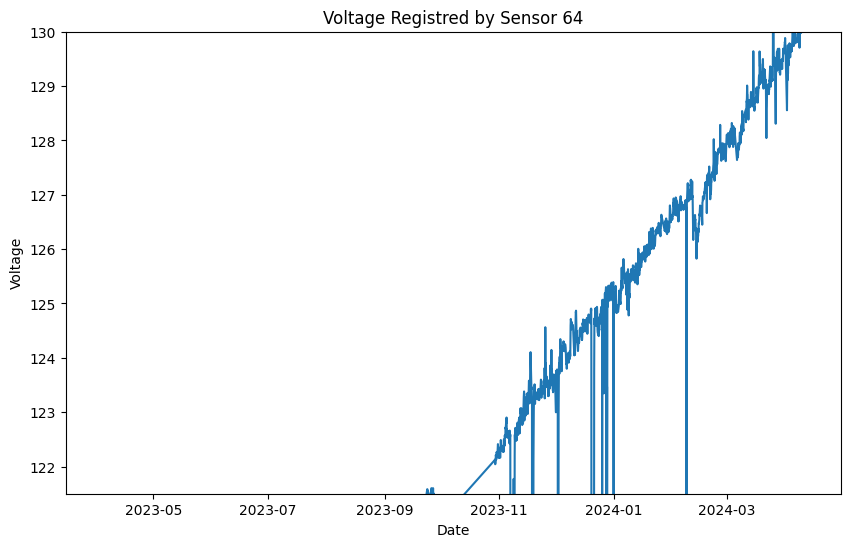

In [5]:
plt.figure(figsize=(10, 6))
sns.lineplot(data = data, y='sensor 64', x='Date')
plt.title('Voltage Registred by Sensor 64')
plt.ylim(121.5, 130)
plt.xlabel('Date')
plt.ylabel('Voltage')
plt.show()

In [6]:
data = data[data['sensor 64'] > 121.5 ]
data['sensor 64'].describe()

count    3535.000000
mean      126.045716
std         2.278536
min       121.500961
25%       124.214188
50%       126.007869
75%       127.876224
max       130.398127
Name: sensor 64, dtype: float64

In [7]:
average_s64 = data.groupby(data['Date'].dt.date)['sensor 64'].mean()
average_s64 = average_s64.reset_index()
average_s64.rename(columns={'Date': 'average_daily'}, inplace=True)
average_s64

,average_daily,sensor 64
0,2023-09-23,121.566813
1,2023-09-25,121.581568
2,2023-09-26,121.556520
3,2023-09-27,121.502602
4,2023-10-29,122.075067
...,...,...
163,2024-04-07,129.871961
164,2024-04-08,130.174848
165,2024-04-09,130.113218
166,2024-04-10,130.129586


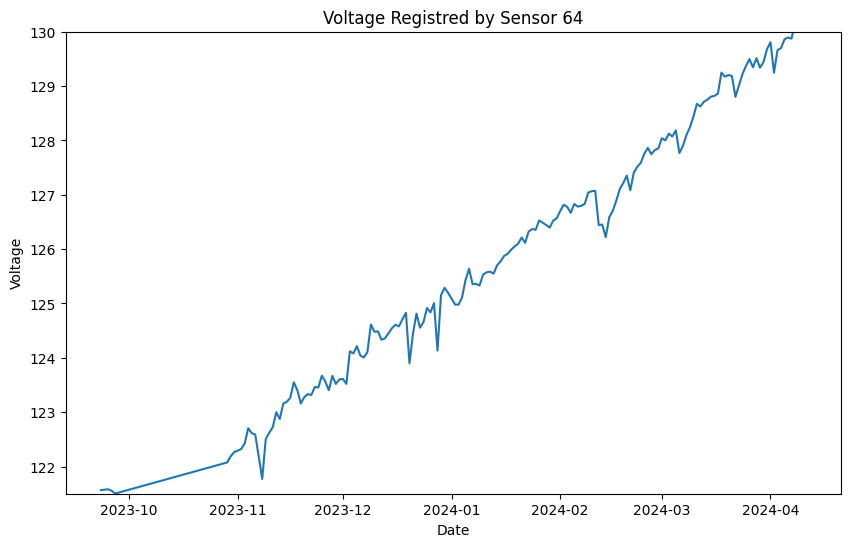

In [8]:
plt.figure(figsize=(10, 6))
sns.lineplot(data = average_s64, x='average_daily', y='sensor 64')
plt.title('Voltage Registred by Sensor 64')
plt.ylim(121.5, 130)
plt.xlabel('Date')
plt.ylabel('Voltage')
plt.show()

In [9]:
average_s64['diff'] = average_s64['sensor 64'].diff()
average_s64.dropna(inplace=True)
average_s64.head(3)

,average_daily,sensor 64,diff
1,2023-09-25,121.581568,0.014755
2,2023-09-26,121.556520,-0.025048
3,2023-09-27,121.502602,-0.053919


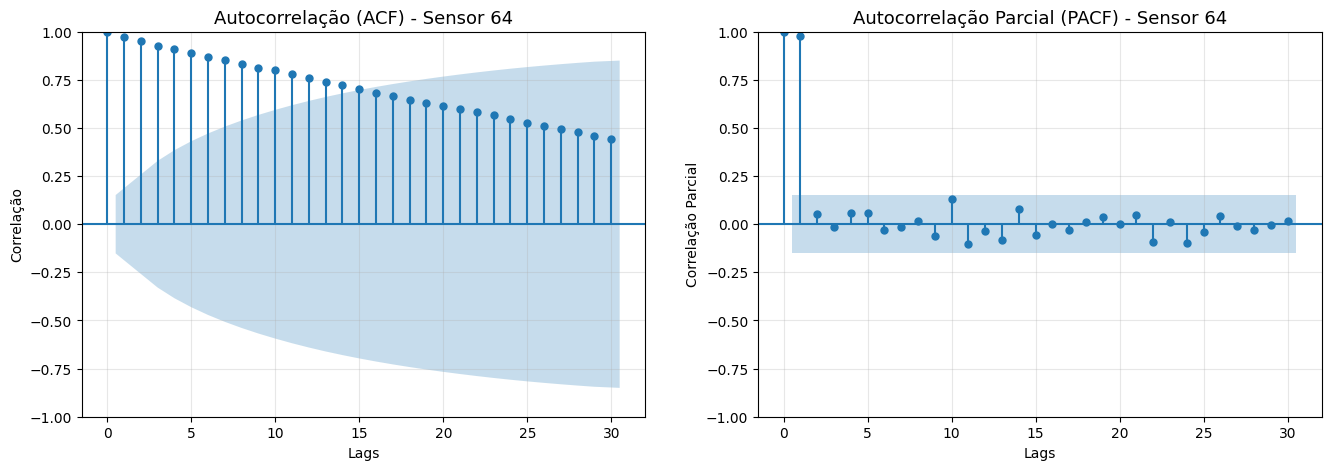

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(average_s64['sensor 64'], lags=30, ax=axes[0], alpha=0.05)
axes[0].set_title('Autocorrelação (ACF) - Sensor 64', fontsize=13)
axes[0].set_xlabel('Lags')
axes[0].set_ylabel('Correlação')
axes[0].grid(True, alpha=0.3)

plot_pacf(average_s64['sensor 64'], lags=30, method='yw', ax=axes[1], alpha=0.05)
axes[1].set_title('Autocorrelação Parcial (PACF) - Sensor 64', fontsize=13)
axes[1].set_xlabel('Lags')
axes[1].set_ylabel('Correlação Parcial')
axes[1].grid(True, alpha=0.3)

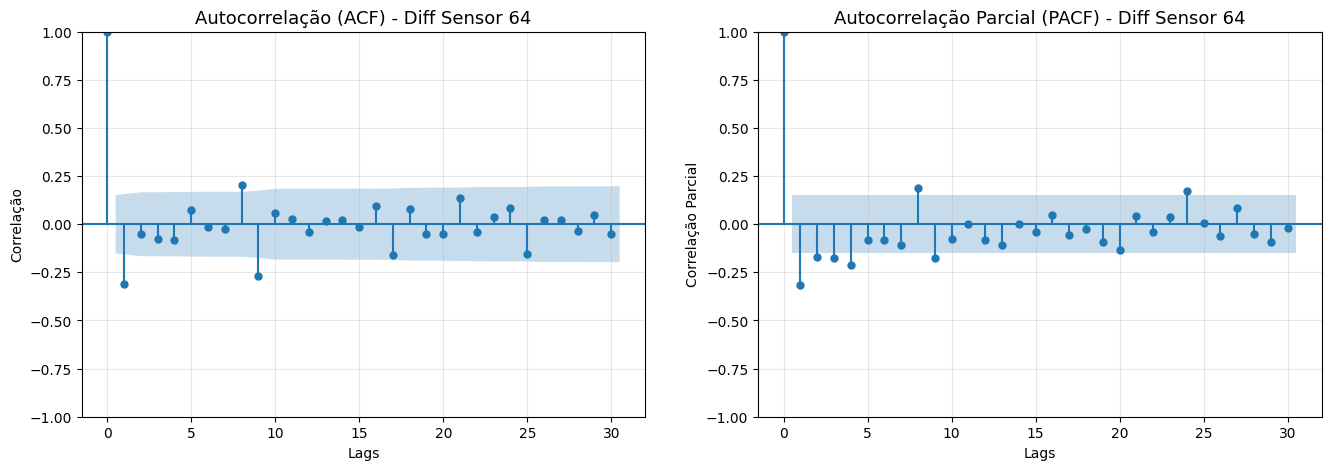

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(average_s64['diff'], lags=30, ax=axes[0], alpha=0.05)
axes[0].set_title('Autocorrelação (ACF) - Diff Sensor 64', fontsize=13)
axes[0].set_xlabel('Lags')
axes[0].set_ylabel('Correlação')
axes[0].grid(True, alpha=0.3)

plot_pacf(average_s64['diff'], lags=30, method='yw', ax=axes[1], alpha=0.05)
axes[1].set_title('Autocorrelação Parcial (PACF) - Diff Sensor 64', fontsize=13)
axes[1].set_xlabel('Lags')
axes[1].set_ylabel('Correlação Parcial')
axes[1].grid(True, alpha=0.3)

## Features

Separating into test and training sets

In [12]:
for i in range(1, 3, 1):
        average_s64[f'shift_{i}'] = average_s64['sensor 64'].shift(i)
average_s64.dropna(inplace=True)

y = average_s64['sensor 64'].values.reshape(-1, 1).astype('float32')
X = average_s64[[f'shift_{i}' for i in range(1, 3)]].values.astype('float32')  # Usando os valores dos 8 dias anteriores como recursos


X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, shuffle=False)


In [13]:
preview = pd.DataFrame(X_train, columns=[f'shift_{i}' for i in range(1, 3)])
preview.head(3)

,shift_1,shift_2
0,121.556519,121.581566
1,121.502602,121.556519
2,122.075066,121.502602


In [14]:
X.shape, y.shape, X_train.shape, y_train.shape, X_test.shape, y_test.shape, X_val.shape, y_val.shape

((165, 2), (165, 1), (99, 2), (99, 1), (33, 2), (33, 1), (33, 2), (33, 1))

Normalizando dados

In [15]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) 
X_val_scaled = scaler.transform(X_val) 

y_train_scaled = scaler.fit_transform(y_train)
y_test_scaled = scaler.transform(y_test)
y_val_scaled = scaler.transform(y_val)

Hiperparâmetros

In [16]:
hiperparametros = {
    'TAXA_DE_APRENDIZADO': 0.001,
    'EPOCAS': 150,
    'TAMANHO_LOTE': 64,
    'ENTRADAS': 32,
    'UNIDADES_OCULTAS': 16,
    'ATIVACAO': 'tanh',
    'RANDOM_STATE': 42,
    'VALIDACAO': (X_val_scaled, y_val_scaled),
    "PATIENCE": 10
    
}

Aplicando o treinamento

In [17]:
#Construção da arquitetura

# Garantindo a reprodutibilidade
os.environ['PYTHONHASHSEED'] = str(hiperparametros['RANDOM_STATE'])
random.seed(hiperparametros['RANDOM_STATE'])
np.random.seed(hiperparametros['RANDOM_STATE'])
tf.random.set_seed(hiperparametros['RANDOM_STATE'])


#Camada de Entrada
model_mlp = Sequential([Dense(hiperparametros['ENTRADAS'], # 64 Neurônio nesta camada (Z = W*X + b)
                                  input_shape=(X_train_scaled.shape[1],), # Quantidade de variáveis que vão entrar ( Z = w1*x1 + w2*x2 + b)
                                  activation=hiperparametros['ATIVACAO']) ]) # Especificando qual vai ser o tipo de ativação. Ex: reLu, linear, tanh, sigmoid...

#Dropout entre as camadas para evitar overfitting
#model_mlp.add(Dropout(hiperparametros['DROPOUT_RATE'])) # Adiciona uma camada de Dropout para ajudar a prevenir overfitting, desligando aleatoriamente 20% dos neurônios durante o treinamento

#Camada Oculta 1
model_mlp.add(Dense(hiperparametros['UNIDADES_OCULTAS'], activation=hiperparametros['ATIVACAO']))

#Dropout entre as camadas para evitar overfitting
#model_mlp.add(Dropout(hiperparametros['DROPOUT_RATE'])) # Adiciona uma camada de Dropout para ajudar a prevenir overfitting, desligando aleatoriamente 20% dos neurônios durante o treinamento

#Camada de Saída
model_mlp.add(Dense(1, activation='linear')) # 1 Neurônio nesta camada (Z = W*X + b) 


#Configuração
model_mlp.compile(
    optimizer=Adam(learning_rate=hiperparametros['TAXA_DE_APRENDIZADO']), #Aplicação do modelo de Gradiente descendente, usando o leanning rate proposto
    loss='mse', # Qual a função da loss. Nesse caso o mse é (Z - F(x1,x2))²
    metrics=['mae'] # Erro Médio Absoluto para termos uma métrica mais legível
)


## Define a regra de parada
parada_antecipada = EarlyStopping(
    monitor='val_loss', # Fica de olho no erro de validação
    patience=hiperparametros['PATIENCE'],        # Se o erro não cair por 10 épocas seguidas, ele para
    restore_best_weights=True # Garante que você ficará com os melhores pesos encontrados
)



#Treinamento
historico = model_mlp.fit(
    X_train_scaled, y_train_scaled, #Indica quais são as bases
    epochs=hiperparametros['EPOCAS'], 
    batch_size=hiperparametros['TAMANHO_LOTE'], #O batch_size é a batelada de cada iteração (epoch) que será calculada
    validation_data=hiperparametros['VALIDACAO'], #Indica qual é a base de validação
    shuffle=False, # Manter a ordem temporal dos dados
    verbose=1, # Mude para 1 se quiser ver o log de cada época,
    callbacks=[parada_antecipada] # Early Stopping para evitar overfitting
)

c:\Projeto de Manutenção\Maintenance-prediction\.venv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step - loss: 0.9227 - mae: 0.8809 - val_loss: 2.5767 - val_mae: 1.5988
Epoch 2/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.7740 - mae: 0.8024 - val_loss: 2.2148 - val_mae: 1.4819
Epoch 3/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.6438 - mae: 0.7279 - val_loss: 1.8841 - val_mae: 1.3664
Epoch 4/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.5279 - mae: 0.6548 - val_loss: 1.5857 - val_mae: 1.2531
Epoch 5/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.4259 - mae: 0.5832 - val_loss: 1.3194 - val_mae: 1.1425
Epoch 6/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.3375 - mae: 0.5144 - val_loss: 1.0841 - val_mae: 1.0350
Epoch 7/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.2620 - mae: 0.4483 - val_loss: 0.8787 - val_mae: 0.9312
Epoch 8/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.1986 - mae: 0.3855 - val_loss: 0.7017 - val_mae: 0.8313
Epoch 9/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.1466 - mae:

In [18]:
model_mlp.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,925 (7.52 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,284 (5.02 KB)

In [19]:
# get_weights() retorna uma lista: o primeiro item é a matriz de pesos (W), o segundo é o viés (b)
pesos, vies = model_mlp.get_layer(index=0).get_weights()

print(f"pesos: {pesos.flatten()} e o viés: {vies[0]:.4f}")

pesos: [ 0.32519463  0.11863559 -0.09406757  0.35346618 -0.3808432   0.15193377
  0.3706181  -0.30502576  0.04449284  0.08659463 -0.3731581  -0.03789912
  0.36837777 -0.00043582  0.0336436   0.20202309 -0.3837983  -0.23752421
 -0.00263603 -0.34272897 -0.36501634  0.26636624  0.33174494 -0.17373781
  0.3290539  -0.3385636  -0.0573567   0.077245    0.08283322 -0.2763777
 -0.25734577  0.42590895 -0.30352312 -0.06533424 -0.1727521  -0.34298092
  0.16955636 -0.24296565  0.12766258  0.10038307 -0.3597901   0.03022773
 -0.16502464 -0.08798424  0.35873955 -0.05082793  0.05761769 -0.2267568
 -0.29647392  0.20222843  0.08324772  0.02820094 -0.37334493 -0.3454937
  0.22758113  0.3333962  -0.03028509 -0.18203342 -0.41795543 -0.36305535
  0.24443875  0.25165403 -0.11770149  0.19943082] e o viés: 0.0245


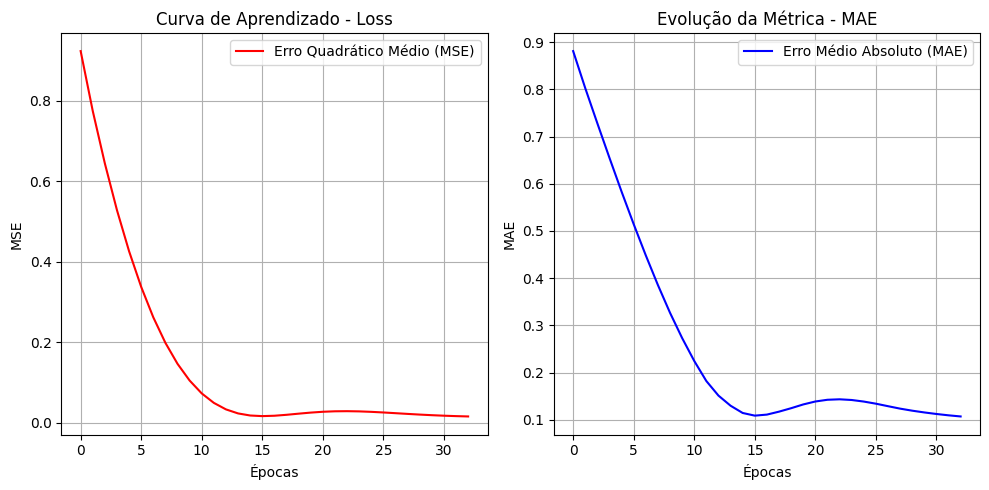

In [20]:
plt.figure(figsize=(10, 5))

# Plotando a Perda (MSE)
plt.subplot(1, 2, 1)
plt.plot(historico.history['loss'], label='Erro Quadrático Médio (MSE)', color='red')
plt.title('Curva de Aprendizado - Loss')
plt.xlabel('Épocas')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)

# Plotando a Métrica (MAE)
plt.subplot(1, 2, 2)
plt.plot(historico.history['mae'], label='Erro Médio Absoluto (MAE)', color='blue')
plt.title('Evolução da Métrica - MAE')
plt.xlabel('Épocas')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [21]:
erro_simples = model_mlp.evaluate(X_test_scaled, y_test, verbose=0)[1]
print(f"Erro Médio Absoluto (Simples): {erro_simples:.2f}\n")

Erro Médio Absoluto (Simples): 128.21



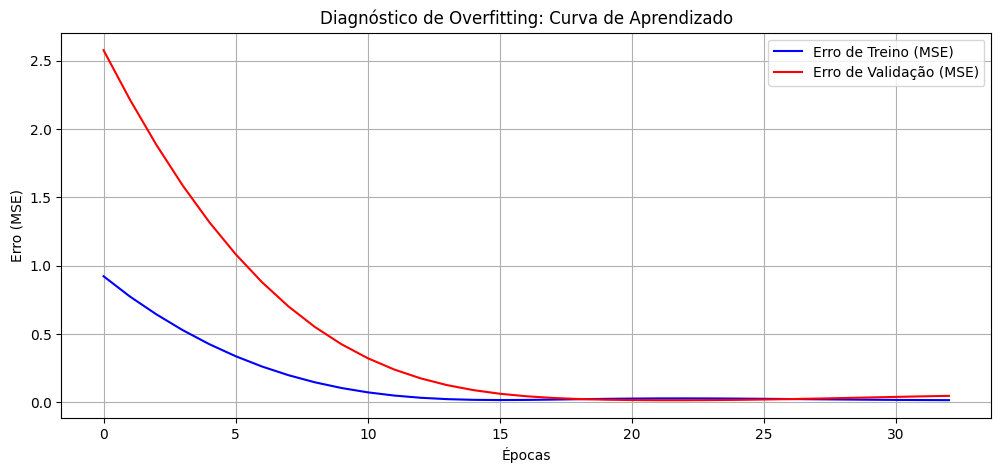

In [22]:
# Criando a figura para as curvas de perda (Loss)
plt.figure(figsize=(12, 5))

# Plotando a Perda de Treino
plt.plot(historico.history['loss'], label='Erro de Treino (MSE)', color='blue')

# Plotando a Perda de Validação (se você passou validation_data no fit)
if 'val_loss' in historico.history:
    plt.plot(historico.history['val_loss'], label='Erro de Validação (MSE)', color='red')

plt.title('Diagnóstico de Overfitting: Curva de Aprendizado')
plt.xlabel('Épocas')
plt.ylabel('Erro (MSE)')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
epoca_restaurada = parada_antecipada.best_epoch + 1

print(f"Época usada:{epoca_restaurada}")

Época usada:23


In [27]:
val_mae = historico.history['val_mae'][parada_antecipada.best_epoch]
mae = historico.history['mae'][parada_antecipada.best_epoch]

print(f"Melhor Val MAE: {val_mae:.4f}")
print(f"Melhor MAE: {mae:.4f}")

val_rmse = np.sqrt(historico.history['val_loss'][parada_antecipada.best_epoch])
rmse = np.sqrt(historico.history['loss'][parada_antecipada.best_epoch])
print(f"Melhor Val RMSE: {val_rmse:.4f}")
print(f"Melhor RMSE: {rmse:.4f}")

Melhor Val MAE: 0.1112
Melhor MAE: 0.1435
Melhor Val RMSE: 0.1245
Melhor RMSE: 0.1705


In [ ]:
# Supondo que você tenha seus dados originais já escalonados em X_scaled e y_scaled
proporcao_treino = 0.8 # 80% para treino, 20% para validação
tamanho_treino = int(len(X_train_scaled) * proporcao_treino)

# Pegamos do início até o ponto de corte
X_train_scaled = X_train_scaled[:tamanho_treino]
y_train_scaled = y_train_scaled[:tamanho_treino]

# Pegamos do ponto de corte até o final para validação
X_val_scaled = X_train_scaled[tamanho_treino:]
y_val_scaled = y_train_scaled[tamanho_treino:]

# Atualizando seu dicionário para encaixar no seu .fit() atual
hiperparametros['VALIDACAO'] = (X_val_scaled, y_val_scaled)

NameError: name 'X_scaled' is not defined